# Preprocessing data

In [4]:
import pandas as pd
import re
from google.colab import drive

# Mount drive (akan minta izin lagi karena ini Colab baru)
drive.mount('/content/drive')

# Load data yang tadi disave
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/raw_review_netflix.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## membuang data kosong dan duplikat

In [5]:
df = df.dropna(subset=['content'])
df = df.drop_duplicates(subset=['content'])

## cleaning text

In [6]:
def clean_text(text):
    text = str(text).lower() # Ubah ke huruf kecil
    text = re.sub(r'[^a-z\s]', '', text) # Buang semua selain huruf a-z dan spasi (termasuk emoji & angka)
    text = re.sub(r'\s+', ' ', text).strip() # Rapikan spasi yang berlebihan
    return text

In [7]:
df['clean_content'] = df['content'].apply(clean_text)

In [8]:
print(f"Sisa data setelah hapus duplikat: {len(df)}")
df[['content', 'clean_content']].head()

Sisa data setelah hapus duplikat: 9558


,content,clean_content
0,"banyakin dracin nya dong, soalnya ga suka drakor",banyakin dracin nya dong soalnya ga suka drakor
1,susah bgt si login nya! email ini lah link ini...,susah bgt si login nya email ini lah link ini ...
2,jelek bgt masa ada masalah kasih bintang 1 dlu,jelek bgt masa ada masalah kasih bintang dlu
3,berlangganan netflix per bulan sekarang cuma d...,berlangganan netflix per bulan sekarang cuma d...
4,mantap,mantap


# Normalisasi

In [9]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 8.2 MB/s eta 0:00:00


In [11]:
import pandas as pd
import re
from tqdm import tqdm
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Aktifkan progress bar untuk Pandas
tqdm.pandas()

# 1. Kamus bahasa slang
kamus_alay = {
    "bgt": "banget", "bgst": "bangsat", "jlk": "jelek",
    "cpet": "cepat", "gak": "tidak", "gk": "tidak", "ngga": "tidak", "nggak": "tidak",
    "baguss": "bagus", "bgs": "bagus", "mantap": "bagus",
    "sy": "saya", "jg": "juga", "nntn": "nonton", "klo": "kalau",
    "udh": "sudah", "blm": "belum", "bnyk": "banyak"
}

def normalisasi_alay(text):
    words = str(text).split()
    normalized_words = [kamus_alay.get(word, word) for word in words]
    return ' '.join(normalized_words)

# 2. Stopwords & Stemmer
factory_stopwords = StopWordRemoverFactory()
stopwords = factory_stopwords.get_stop_words()
stopwords.extend(['netflix', 'aplikasi', 'film', 'nya', 'sih', 'dong', 'deh'])

def hapus_stopwords(text):
    words = str(text).split()
    filtered_words = [word for word in words if word not in stopwords]
    return ' '.join(filtered_words)

factory_stemmer = StemmerFactory()
stemmer = factory_stemmer.create_stemmer()

def stemming(text):
    return stemmer.stem(str(text))

# ==========================================
# 3. EKSEKUSI SEMUA DATA (11.000 Baris)
# ==========================================
print("1. Membersihkan simbol dan huruf kecil")
df['text_bersih'] = df['content'].astype(str).str.lower()
df['text_bersih'] = df['text_bersih'].apply(lambda x: re.sub(r'[^a-z\s]', '', x))
df['text_bersih'] = df['text_bersih'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

print("2. Normalisasi kata slang")
df['text_bersih'] = df['text_bersih'].progress_apply(normalisasi_alay)

print("3. Menghapus Stopwords")
df['text_bersih'] = df['text_bersih'].progress_apply(hapus_stopwords)

print("4. Stemming")
df['text_bersih'] = df['text_bersih'].progress_apply(stemming)

# 5. SAVE
lokasi_simpan_bersih = '/content/drive/MyDrive/Colab Notebooks/clean_review_netflix.csv'
df.to_csv(lokasi_simpan_bersih, index=False)

print(f"Data bersih sudah disave di: {lokasi_simpan_bersih}")
df[['content', 'text_bersih']].head()

1. Membersihkan simbol dan huruf kecil
2. Normalisasi kata slang


100%|██████████| 9558/9558 [00:00<00:00, 194623.62it/s]


3. Menghapus Stopwords


100%|██████████| 9558/9558 [00:00<00:00, 61731.38it/s]


4. Stemming


100%|██████████| 9558/9558 [15:23<00:00, 10.35it/s]

Data bersih sudah disave di: /content/drive/MyDrive/Colab Notebooks/clean_review_netflix.csv


,content,text_bersih
0,"banyakin dracin nya dong, soalnya ga suka drakor",banyakin dracin soal ga suka drakor
1,susah bgt si login nya! email ini lah link ini...,susah banget si login email lah link lah gabis...
2,jelek bgt masa ada masalah kasih bintang 1 dlu,jelek banget masa masalah kasih bintang dlu
3,berlangganan netflix per bulan sekarang cuma d...,langgan per bulan sekarang cuma dijatahin hari...
4,mantap,bagus


# Pelabelan

In [12]:
# Fungsi untuk melabeli skor menjadi sentimen
def tentukan_sentimen(score):
    if score <= 2:
        return 'negatif'
    elif score == 3:
        return 'netral'
    else:
        return 'positif'

# Terapkan fungsi ke kolom 'score' dan buat kolom baru 'sentimen'
df['sentimen'] = df['score'].apply(tentukan_sentimen)

# Mengecek beberapa baris untuk memastikan berhasil
df[['score', 'sentimen', 'content', 'text_bersih']].head(10)

,score,sentimen,content,text_bersih
0,1,negatif,"banyakin dracin nya dong, soalnya ga suka drakor",banyakin dracin soal ga suka drakor
1,1,negatif,susah bgt si login nya! email ini lah link ini...,susah banget si login email lah link lah gabis...
2,1,negatif,jelek bgt masa ada masalah kasih bintang 1 dlu,jelek banget masa masalah kasih bintang dlu
3,1,negatif,berlangganan netflix per bulan sekarang cuma d...,langgan per bulan sekarang cuma dijatahin hari...
4,5,positif,mantap,bagus
5,5,positif,Sistem pembayarannya cuma bisa pakai kartu ya?...,sistem bayar cuma pakai kartu ga simple aja al...
6,4,positif,ok,
7,1,negatif,TOLONG HAPUS SEMUANYA FILM YANG BERASAL DARI K...,hapus semua asal korea jelek nonton plastik
8,1,negatif,bayar nya ke mahalan+GX lengkap video nya+ngel...,bayar mahalangx lengkap video nyangeleg ngeleg...
9,1,negatif,"gak bisa login, padahal email udah bener",login padahal email udah bener


/tmp/ipython-input-3994/4231224453.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentimen', data=df, palette='Set2', order=['negatif', 'netral', 'positif'])


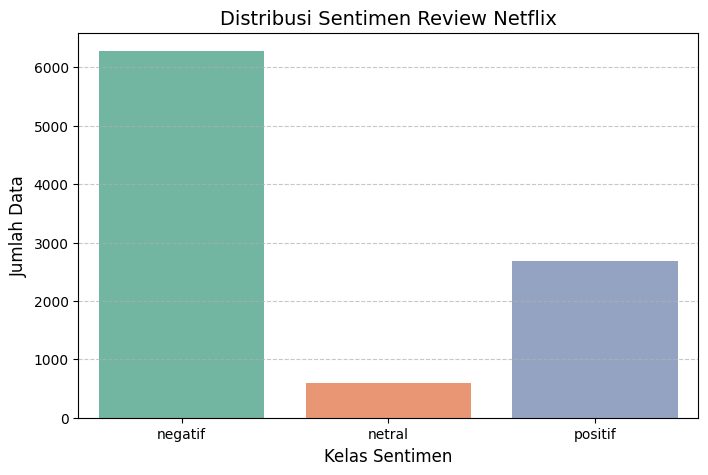


Jumlah data per kelas sentimen:
sentimen
negatif    6278
positif    2680
netral      600
Name: count, dtype: int64


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

df['sentimen'] = df['score'].apply(tentukan_sentimen)

# Visualisasi Distribusi Kelas Sentimen
plt.figure(figsize=(8, 5))
sns.countplot(x='sentimen', data=df, palette='Set2', order=['negatif', 'netral', 'positif'])

plt.title('Distribusi Sentimen Review Netflix', fontsize=14)
plt.xlabel('Kelas Sentimen', fontsize=12)
plt.ylabel('Jumlah Data', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Tampilkan angka pasti per kelas
print("\nJumlah data per kelas sentimen:")
print(df['sentimen'].value_counts())

# Oversampling

In [14]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [15]:
!pip install imbalanced-learn

In [16]:
from imblearn.over_sampling import SMOTE

In [19]:
df = df.dropna(subset=['text_bersih'])

print("1. Mengubah teks menjadi angka (TF-IDF)...")
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['text_bersih'])
y = df['sentimen']

print("2. Melakukan Oversampling dengan SMOTE...")
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

print(f"Total data SEBELUM SMOTE: {len(y)}")
print(f"Total data SESUDAH SMOTE: {len(y_smote)}")

# 4. SPLIT DATA (Bagi jadi data latih dan data uji 80:20)
print("3. Membagi data latih dan uji...")
X_train, X_test, y_train, y_test = train_test_split(X_smote, y_smote, test_size=0.2, random_state=42)

1. Mengubah teks menjadi angka (TF-IDF)...
2. Melakukan Oversampling dengan SMOTE...
Total data SEBELUM SMOTE: 9558
Total data SESUDAH SMOTE: 18834
3. Membagi data latih dan uji...


# MODELING
- SVM
- Naive Bayes
- Random Forest
- Multi Layer Perceptron

In [20]:
import pandas as pd
import numpy as np
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Preprocessing data untuk DL

In [21]:
le = LabelEncoder()
y_train_dl = le.fit_transform(y_train)
y_test_dl = le.transform(y_test)

In [22]:
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

# Training model ML

In [24]:
print("Mulai training model ML")
ml_models = {
    "1. Support Vector Machine (SVM)": LinearSVC(random_state=42),
    "2. Naive Bayes": MultinomialNB(),
    "3. Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

akurasi_ml = {}

for nama, model in ml_models.items():
    print(f"Training {nama}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    akurasi_ml[nama] = acc
    print(f"Akurasi {nama}: {acc * 100:.2f}%\n")

Mulai training model ML
Training 1. Support Vector Machine (SVM)...
Akurasi 1. Support Vector Machine (SVM): 81.98%

Training 2. Naïve Bayes...
Akurasi 2. Naïve Bayes: 77.44%

Training 3. Random Forest...
Akurasi 3. Random Forest: 89.83%



# Training model DL

In [25]:
print("Membangun arsitektur Deep Learning (ANN)")

# Bikin model sekuensial
model_dl = Sequential([
    # Layer Input & Hidden Layer 1
    Dense(128, activation='relu', input_shape=(X_train_dense.shape[1],)),
    Dropout(0.5),

    # Hidden Layer 2
    Dense(64, activation='relu'),
    Dropout(0.3),

    # Layer Output (3 neuron karena punya 3 sentimen: negatif, netral, positif)
    Dense(3, activation='softmax')
])

Membangun arsitektur Deep Learning (ANN)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
# Compile model DL
model_dl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
print("Training Deep Learning dimulai (Epochs=5)")
# Proses training DL
history = model_dl.fit(
    X_train_dense, y_train_dl,
    epochs=5,
    batch_size=32,
    validation_split=0.1, #10% data train buat validasi internal
    verbose=1
)

Training Deep Learning dimulai (Epochs=5)
Epoch 1/5
424/424 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.5385 - loss: 0.9350 - val_accuracy: 0.8056 - val_loss: 0.5365
Epoch 2/5
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8362 - loss: 0.4553 - val_accuracy: 0.8640 - val_loss: 0.4037
Epoch 3/5
424/424 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9009 - loss: 0.2967 - val_accuracy: 0.8772 - val_loss: 0.3673
Epoch 4/5
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9270 - loss: 0.2161 - val_accuracy: 0.8859 - val_loss: 0.3692
Epoch 5/5
424/424 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9443 - loss: 0.1663 - val_accuracy: 0.8879 - val_loss: 0.3718


In [29]:
# Evaluasi Deep Learning
print("\nMenghitung akurasi Deep Learning di Data Test...")
loss, acc_dl = model_dl.evaluate(X_test_dense, y_test_dl, verbose=0)


Menghitung akurasi Deep Learning di Data Test...


In [30]:
for nama, acc in akurasi_ml.items():
    print(f"{nama.ljust(35)}: {acc * 100:.2f}%")
print(f"{'4. Deep Learning (ANN)'.ljust(35)}: {acc_dl * 100:.2f}%")

1. Support Vector Machine (SVM)    : 81.98%
2. Naïve Bayes                     : 77.44%
3. Random Forest                   : 89.83%
4. Deep Learning (ANN)             : 89.43%


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# 1. UPGRADE TF-IDF (N-Gram: 1 kata dan 2 kata berurutan)
print("1. Ekstraksi Fitur ulang dengan N-Gram (Unigram & Bigram)...")

vectorizer_ngram = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_ngram = vectorizer_ngram.fit_transform(df['text_bersih'])

# 2. SMOTE
print("2. Resampling ulang dengan SMOTE...")
smote = SMOTE(random_state=42)
X_smote_ng, y_smote_ng = smote.fit_resample(X_ngram, y)

# 3. SPLIT DATA
print("3. Membagi data latih dan uji...")
X_train_ng, X_test_ng, y_train_ng, y_test_ng = train_test_split(
    X_smote_ng, y_smote_ng, test_size=0.2, random_state=42
)

# 4. RETRAIN RANDOM FOREST
print("4. Training ulang Random Forest dengan fitur N-Gram berjalan...\n")
rf_ngram = RandomForestClassifier(n_estimators=100, random_state=42)
rf_ngram.fit(X_train_ng, y_train_ng)

# 5. EVALUASI HASIL BARU
y_pred_ng = rf_ngram.predict(X_test_ng)
acc_ng = accuracy_score(y_test_ng, y_pred_ng)

print(f"AKURASI RANDOM FOREST (N-GRAM): {acc_ng * 100:.2f}%")

1. Ekstraksi Fitur ulang dengan N-Gram (Unigram & Bigram)...
2. Resampling ulang dengan SMOTE...
3. Membagi data latih dan uji...
4. Training ulang Random Forest dengan fitur N-Gram berjalan...

AKURASI RANDOM FOREST (N-GRAM): 89.75%


In [39]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

print("Menjalankan SVM + TF-IDF (N-Gram) + Split 80:20")

# max_iter dinaikkan agar model punya waktu cukup untuk konvergen
svm_ngram = LinearSVC(C=0.5, random_state=42, max_iter=3000)

# Training model
svm_ngram.fit(X_train_ng, y_train_ng)

# Prediksi untuk Data Training dan Data Testing
y_pred_train_svm = svm_ngram.predict(X_train_ng)
y_pred_test_svm = svm_ngram.predict(X_test_ng)

# Hitung akurasi
acc_train_svm = accuracy_score(y_train_ng, y_pred_train_svm)
acc_test_svm = accuracy_score(y_test_ng, y_pred_test_svm)

print(f"AKURASI TRAINING SVM : {acc_train_svm * 100:.2f}%")
print(f"AKURASI TESTING SVM  : {acc_test_svm * 100:.2f}%")

Menjalankan SVM + TF-IDF (N-Gram) + Split 80:20
AKURASI TRAINING SVM : 91.29%
AKURASI TESTING SVM  : 85.13%


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("Random Forest + TF-IDF (N-Gram) + Split 90:10")

# 1. Split Data dengan Rasio Baru (90% Train, 10% Test)
X_train_90, X_test_10, y_train_90, y_test_10 = train_test_split(
    X_smote_ng, y_smote_ng, test_size=0.1, random_state=42
)

# 2. Panggil Random Forest
rf_ultimate = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

# 3. Proses Training
print("Sedang melatih model")
rf_ultimate.fit(X_train_90, y_train_90)

# 4. Evaluasi
y_pred_train_rf = rf_ultimate.predict(X_train_90)
y_pred_test_rf = rf_ultimate.predict(X_test_10)

acc_train_rf = accuracy_score(y_train_90, y_pred_train_rf)
acc_test_rf = accuracy_score(y_test_10, y_pred_test_rf)

print(f"AKURASI TRAINING RF (90:10) : {acc_train_rf * 100:.2f}%")
print(f"AKURASI TESTING RF (90:10)  : {acc_test_rf * 100:.2f}%")

Random Forest + TF-IDF (N-Gram) + Split 90:10
Sedang melatih model
AKURASI TRAINING RF (90:10) : 98.37%
AKURASI TESTING RF (90:10)  : 90.39%


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("Logistic Regression + TF-IDF (N-Gram) + Split 90:10")

# Panggil model Logistic Regression
logreg = LogisticRegression(max_iter=2000, random_state=42)

print("Sedang melatih model Logistic Regression")
logreg.fit(X_train_90, y_train_90)

# Evaluasi Akurasi
y_pred_train_lr = logreg.predict(X_train_90)
y_pred_test_lr = logreg.predict(X_test_10)

acc_train_lr = accuracy_score(y_train_90, y_pred_train_lr)
acc_test_lr = accuracy_score(y_test_10, y_pred_test_lr)

print(f"AKURASI TRAINING LOGREG : {acc_train_lr * 100:.2f}%")
print(f"AKURASI TESTING LOGREG  : {acc_test_lr * 100:.2f}%")

Logistic Regression + TF-IDF (N-Gram) + Split 90:10
Sedang melatih model Logistic Regression
AKURASI TRAINING LOGREG : 87.41%
AKURASI TESTING LOGREG  : 83.12%


# CELL INFERENCE - DEEP LEARNING (ANN)

In [48]:
def prediksi_sentimen_dl(kalimat):
    # 1. Preprocessing
    kalimat_clean = kalimat.lower()
    kalimat_clean = re.sub(r'[^a-z\s]', '', kalimat_clean)

    # 2. Transformasi ke TF-IDF
    kalimat_vector = vectorizer.transform([kalimat_clean]).toarray()

    # 3. Prediksi pakai model Deep Learning
    prediksi_proba = model_dl.predict(kalimat_vector, verbose=0)
    hasil_angka = np.argmax(prediksi_proba) # Ambil index dengan probabilitas tertinggi

    # 4. Balikkan angka ke label teks (le adalah LabelEncoder yang kita buat tadi)
    label_sentimen = le.inverse_transform([hasil_angka])[0]

    return label_sentimen

# --- TEST DRIVE ---
test_kalimat = "Kualitas gambarnya jernih, tapi aplikasinya sering keluar sendiri."
test_kalimat2 = "Jelek banget, gasuka dengan rekomendasinya"
test_kalimat3 = "Sangat suka dengan aplikasi ini, menghibur ketika liburan"
hasil_dl = prediksi_sentimen_dl(test_kalimat)
hasil_dl2 = prediksi_sentimen_dl(test_kalimat2)
hasil_dl3 = prediksi_sentimen_dl(test_kalimat3)

print(f"Kalimat: '{test_kalimat}'")
print(f"Hasil Prediksi DL: {hasil_dl.upper()}")

print(f"Kalimat: '{test_kalimat2}'")
print(f"Hasil Prediksi DL: {hasil_dl2.upper()}")

print(f"Kalimat: '{test_kalimat3}'")
print(f"Hasil Prediksi DL: {hasil_dl3.upper()}")

Kalimat: 'Kualitas gambarnya jernih, tapi aplikasinya sering keluar sendiri.'
Hasil Prediksi DL: NETRAL
Kalimat: 'Jelek banget, gasuka dengan rekomendasinya'
Hasil Prediksi DL: NEGATIF
Kalimat: 'Sangat suka dengan aplikasi ini, menghibur ketika liburan'
Hasil Prediksi DL: POSITIF


# Requirements

In [50]:
lokasi_drive = '/content/drive/MyDrive/Colab Notebooks/requirements.txt'

# Daftar library utama yang kita pakai selama proyek ini
libraries = [
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "google-play-scraper",
    "PySastrawi",
    "tqdm",
    "tensorflow",
    "imbalanced-learn"
]

# Tulis file langsung ke lokasi Drive
with open(lokasi_drive, 'w') as f:
    for lib in libraries:
        f.write(f"{lib}\n")

print(f"File requirements.txt berhasil diamankan di: {lokasi_drive}")

File requirements.txt berhasil diamankan di: /content/drive/MyDrive/Colab Notebooks/requirements.txt
